# Cylindrical Geometry Correction for Neutron Transmission Imaging

## Overview

This notebook demonstrates a comprehensive approach to correcting geometric effects and removing background noise in neutron transmission imaging of cylindrical samples, with a focus on Time-of-Flight (TOF) measurements.

In [1]:
# Standard library
from dataclasses import dataclass
from glob import glob
from pathlib import Path
from typing import Any, Dict, List, Literal, Optional, Sequence, Tuple
from pprint import pprint

# Third-party libraries
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
import numpy as np
import pandas as pd
from pydantic import BaseModel, Field, field_validator, model_validator
from scipy import ndimage
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from tifffile import imread
from tqdm.auto import tqdm

## Load Data and Construct Hyperspectral Radiograph

In [2]:
data_dir = Path("/Users/8cz/tmp/ni_powder_data/normalized_sample_Run_7815_obs_Run_7816/stack")
tiff_files = glob(str(data_dir / "*.tif"))
# Sort files by file name
tiff_files.sort()
# show the first 5 files
for i in range(5):
    print(tiff_files[i])

/Users/8cz/tmp/ni_powder_data/normalized_sample_Run_7815_obs_Run_7816/stack/image0000.tif
/Users/8cz/tmp/ni_powder_data/normalized_sample_Run_7815_obs_Run_7816/stack/image0001.tif
/Users/8cz/tmp/ni_powder_data/normalized_sample_Run_7815_obs_Run_7816/stack/image0002.tif
/Users/8cz/tmp/ni_powder_data/normalized_sample_Run_7815_obs_Run_7816/stack/image0003.tif
/Users/8cz/tmp/ni_powder_data/normalized_sample_Run_7815_obs_Run_7816/stack/image0004.tif


In [3]:
# Load all images to create the hyperspectral stack
hyperspectral_stack = []
for tif_file in tqdm(tiff_files, desc="Loading TIFF files", leave=False):
    hyperspectral_stack.append(imread(tif_file))
# Stack the images along a new dimension
hyperspectral_stack = np.stack(hyperspectral_stack, axis=-1)

Loading TIFF files:   0%|          | 0/2782 [00:00<?, ?it/s]

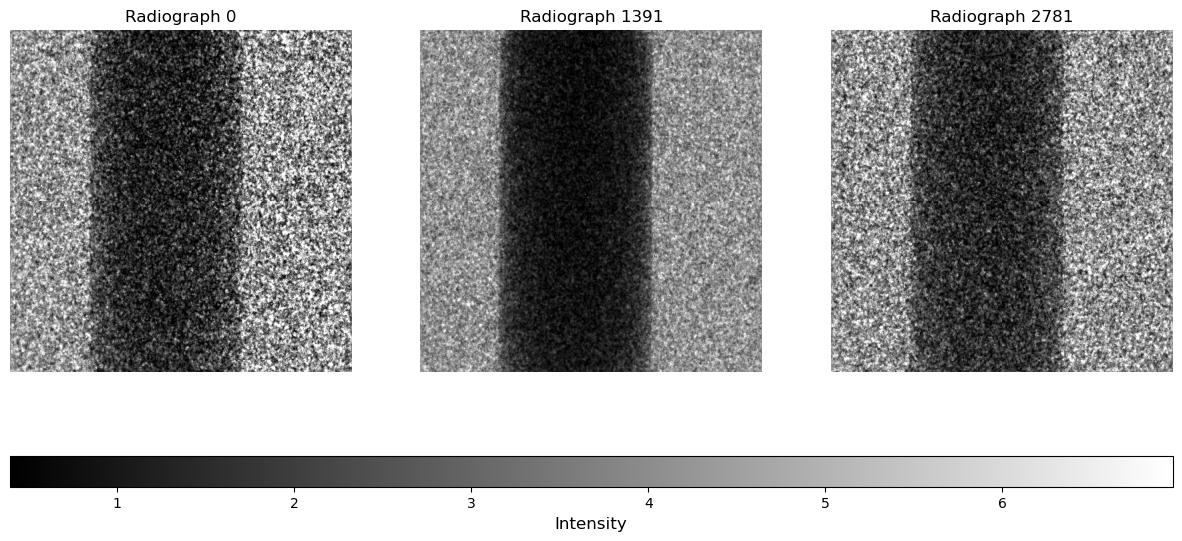

In [4]:
def visualize_hyperspectral_radiographs(hyperspectral_stack: np.ndarray, 
                                       selected_indices: Optional[list[int]] = None, 
                                       figsize: tuple[int, int] = (15, 7), 
                                       cmap: str = "gray", 
                                       percentile_range: tuple[float, float] = (2, 98)) -> plt.Figure:
    """
    Visualize selected radiographs from a hyperspectral stack.
    
    Parameters:
    -----------
    hyperspectral_stack : numpy.ndarray
        3D array with shape (height, width, n_spectral_bins)
    selected_indices : list of int, optional
        Indices of radiographs to visualize. If None, uses beginning, middle, and end.
    figsize : tuple, optional
        Figure size (width, height). Default is (15, 7).
    cmap : str, optional
        Colormap for displaying images. Default is "gray".
    percentile_range : tuple, optional
        Percentile range for intensity scaling (min, max). Default is (2, 98).
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object
    """
    # Default to beginning, middle, and end if no indices provided
    if selected_indices is None:
        n_images = hyperspectral_stack.shape[-1]
        selected_indices = [0, n_images//2, n_images-1]
    
    # Create figure with gridspec layout
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, len(selected_indices), height_ratios=[5, 0.3], hspace=0.01)
    
    # Calculate dynamic range from selected subset
    sub_selection = hyperspectral_stack[..., selected_indices]
    vmin = np.nanpercentile(sub_selection, percentile_range[0])
    vmax = np.nanpercentile(sub_selection, percentile_range[1])
    
    # Create subplots for images in the top row
    img = None  # Will store the last image for colorbar
    for i, idx in enumerate(selected_indices):
        ax = fig.add_subplot(gs[0, i])
        ax.set_title(f"Radiograph {idx}")
        img = ax.imshow(hyperspectral_stack[..., idx], cmap=cmap, origin="lower", 
                       vmin=vmin, vmax=vmax)
        ax.axis("off")
    
    # Create colorbar in the bottom row, spanning all columns
    cbar_ax = fig.add_subplot(gs[1, :])
    cbar = plt.colorbar(img, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Intensity', fontsize=12)

    return fig

_ = visualize_hyperspectral_radiographs(hyperspectral_stack)

## Data Cleaning

In [5]:
def replace_nan_with_local_median(data: np.ndarray, 
                                  kernel_size: Tuple[int, int, int] = (3, 3, 3),
                                  max_iterations: int = 10) -> np.ndarray:
    """
    Replace NaN values in a 3D array using local median filtering.
    
    This function ONLY processes small neighborhoods around NaN pixels,
    avoiding expensive computation on the entire dataset.
    
    Parameters:
    -----------
    data : np.ndarray
        3D input array that may contain NaN values
    kernel_size : Tuple[int, int, int]
        Size of the kernel for median filtering in (height, width, depth) format
        Default is (3, 3, 3)
    max_iterations : int
        Maximum number of iterations to replace NaN values
        Default is 10
    
    Returns:
    --------
    np.ndarray
        Array with NaN values replaced by local median values
    """
    # Work on a copy to avoid modifying the original data
    result = data.copy()
    
    # Track initial NaN count
    initial_nan_count = np.sum(np.isnan(result))
    if initial_nan_count == 0:
        return result
    
    print(f"Starting efficient NaN replacement with kernel size {kernel_size}")
    print(f"Initial NaN count: {initial_nan_count}")
    
    # Calculate padding for kernel
    pad_h, pad_w, pad_d = [k // 2 for k in kernel_size]
    
    for iteration in range(max_iterations):
        # Find current NaN locations
        nan_coords = np.argwhere(np.isnan(result))
        current_nan_count = len(nan_coords)
        
        if current_nan_count == 0:
            print(f"All NaN values replaced after {iteration} iterations")
            break
            
        print(f"Iteration {iteration + 1}: {current_nan_count} NaN values remaining")
        
        # Process each NaN pixel individually
        replaced_count = 0
        for coord in nan_coords:
            y, x, z = coord
            
            # Define the local neighborhood bounds
            y_min = max(0, y - pad_h)
            y_max = min(result.shape[0], y + pad_h + 1)
            x_min = max(0, x - pad_w)
            x_max = min(result.shape[1], x + pad_w + 1)
            z_min = max(0, z - pad_d)
            z_max = min(result.shape[2], z + pad_d + 1)
            
            # Extract the local neighborhood
            neighborhood = result[y_min:y_max, x_min:x_max, z_min:z_max]
            
            # Get non-NaN values in the neighborhood
            valid_values = neighborhood[~np.isnan(neighborhood)]
            
            # If we have valid values, compute median and replace
            if len(valid_values) > 0:
                median_value = np.median(valid_values)
                result[y, x, z] = median_value
                replaced_count += 1
                
        print(f"  Replaced {replaced_count} NaN values in this iteration")
        
        # If no progress was made, break
        if replaced_count == 0:
            remaining_nan_count = np.sum(np.isnan(result))
            print(f"No progress made. {remaining_nan_count} NaN values could not be replaced")
            print("(These may be in regions with no valid neighbors)")
            break
    
    final_nan_count = np.sum(np.isnan(result))
    print(f"Final NaN count: {final_nan_count}")
    print(f"Successfully replaced {initial_nan_count - final_nan_count} NaN values")
    
    return result

In [6]:
# Check for NaN values and replace with local median if found
if np.isnan(hyperspectral_stack).any():
    print("Warning: NaN values found in the hyperspectral stack.")
    num_nan_initial = np.sum(np.isnan(hyperspectral_stack))
    print(f"Total NaN values found: {num_nan_initial}")

    # Replace NaN values with local median using a 3x3x3 kernel (default)
    # You can adjust the kernel size based on your data characteristics
    # Larger kernels will provide more smoothing but may blur fine details
    hyperspectral_stack = replace_nan_with_local_median(
        hyperspectral_stack, 
        kernel_size=(3, 3, 3)  # (height, width, spectral_dimension)
    )
    # Verify replacement
    num_nan_final = np.sum(np.isnan(hyperspectral_stack))
    print(f"Final verification: {num_nan_final} NaN values remaining")

else:
    print("No NaN values found in the hyperspectral stack.")

Total NaN values found: 5564
Starting efficient NaN replacement with kernel size (3, 3, 3)
Initial NaN count: 5564
Iteration 1: 5564 NaN values remaining
  Replaced 5564 NaN values in this iteration
All NaN values replaced after 1 iterations
Final NaN count: 0
Successfully replaced 5564 NaN values
Final verification: 0 NaN values remaining


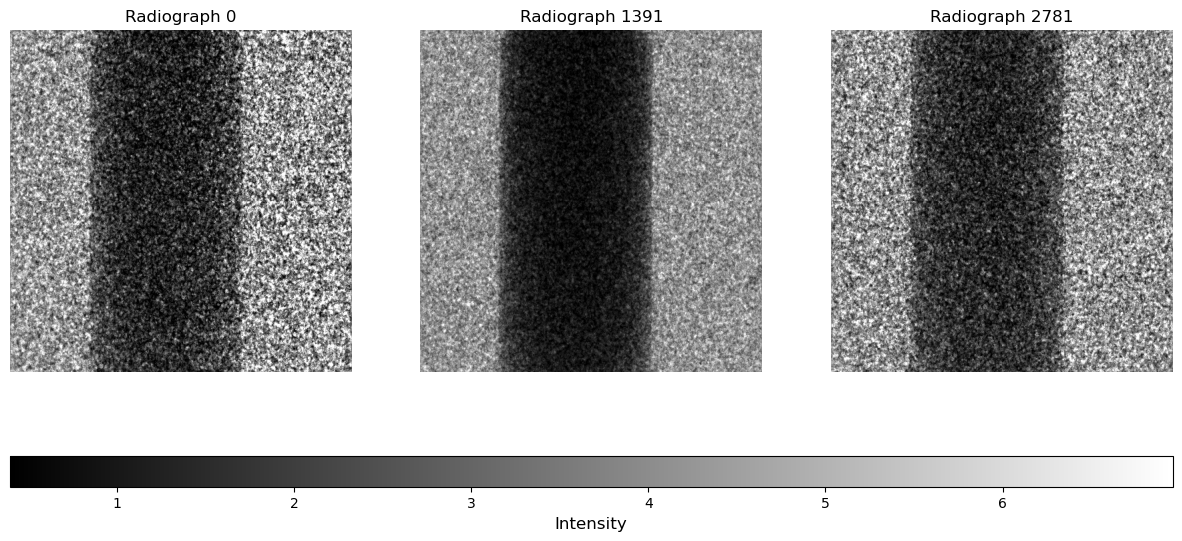

In [7]:
_ = visualize_hyperspectral_radiographs(hyperspectral_stack)

## Cylindrical Geometry Correction

Transmission data in neutron imaging follow the Beer–Lambert law:

$$
T(x,\lambda) = \frac{I(x,\lambda)}{I_0(x,\lambda)} = e^{-\mu(\lambda)\,L(x)}
$$

where:  
- $T(x,\lambda)$ = transmission at column $x$ and wavelength $\lambda$  
- $\mu(\lambda)$ = wavelength-dependent attenuation coefficient  
- $L(x)$ = chord length through the cylinder at $x$

Because open-beam normalization is often imperfect, $T(x,\lambda)$ can exceed 1 ⚠️.  
To estimate $\mu(\lambda)$ robustly, we use two strategies:

- **Discrete Method (Two-Column):**  
  Select two positions $x_1, x_2$. Then  
  $$
  \mu(\lambda) = -\frac{1}{L(x_2)-L(x_1)} \ln\!\left(\frac{T(x_1,\lambda)}{T(x_2,\lambda)}\right)
  $$  
  Relies on relative differences, making it less sensitive to open-beam errors.

- **Iterative Method (Global Fit):**  
  Fit all columns simultaneously:  
  $$
  -\ln T(x,\lambda) \approx \mu(\lambda)\,L(x) + b(x)
  $$  
  where $b(x)$ accounts for slow background variation.  
  This provides a stable global estimate of $\mu(\lambda)$.

Once $\mu(\lambda)$ is known, we correct the data to a uniform thickness equal to the cylinder diameter $D$:

$$
C(x,\lambda) = e^{-\mu(\lambda)\,(D-L(x))}, \quad 
T^D(x,\lambda) = T(x,\lambda)\,C(x,\lambda)
$$

This correction flattens the cylindrical modulation, producing transmission as if the sample had uniform thickness $D$.

### Auto Cylinder Detection

Neutron transmission is generally low in intensity, especially for energy resolved ones.
So we will need to use the summed image for geometry identification. The target feature to extract are:

- left edge pixel
- right edge pixel
- top edge pixel
- bottom edge pixel
- center of the cylindrical region

The goal here is to get the parameters needed to compute a chord length map, $L(x)$, which represents the path length through the cylinder at each pixel position $x$.

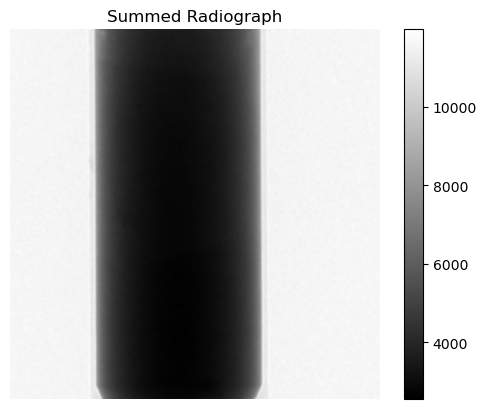

In [8]:
radiograph_summed = np.sum(hyperspectral_stack, axis=-1)
# Visualize the summed radiograph
plt.imshow(radiograph_summed, cmap='gray')
plt.title("Summed Radiograph")
plt.axis("off")
plt.colorbar()
plt.show()

In [9]:
class CylinderGeometry(BaseModel):
    """
    Cylindrical geometry in pixel coordinates (origin: top-left).
    Only store primitives; derive the rest via properties.
    """
    left_edge: int = Field(..., ge=0)
    right_edge: int = Field(..., ge=0)
    top_edge: int = Field(..., ge=0)
    bottom_edge: int = Field(..., ge=0)
    center_x: int = Field(..., ge=0)
    center_y: int = Field(..., ge=0)

    @model_validator(mode="after")
    def _validate_bounds(self):
        if self.right_edge <= self.left_edge:
            raise ValueError("right_edge must be > left_edge")
        if self.bottom_edge <= self.top_edge:
            raise ValueError("bottom_edge must be > top_edge")
        return self

    @property
    def width(self) -> int:
        return self.right_edge - self.left_edge

    @property
    def height(self) -> int:
        return self.bottom_edge - self.top_edge + 1

    @property
    def radius(self) -> int:
        return self.width // 2

    def __str__(self) -> str:
        return (
            "CylinderGeometry(\n"
            f"  Boundaries: left={self.left_edge}, right={self.right_edge}, "
            f"top={self.top_edge}, bottom={self.bottom_edge}\n"
            f"  Center: ({self.center_x}, {self.center_y})\n"
            f"  Dimensions: width={self.width}, height={self.height}, radius={self.radius}\n"
            ")"
        )

In [10]:
@dataclass(slots=True)
class DetectionConfig:
    # horizontal (left/right)
    peak_threshold: float = 0.30   # fraction of max
    peak_distance: int = 20
    smooth_sigma: float = 2.0
    # vertical (top/bottom)
    edge_percentile: float = 90.0
    min_edge_pixels_per_row: int = 3
    # diagnostics
    diagnostics: bool = False


@dataclass(slots=True)
class DetectionDiagnostics:
    edges_x: Optional[np.ndarray] = None
    edges_y: Optional[np.ndarray] = None
    edges_mag: Optional[np.ndarray] = None
    horizontal_profile_smooth: Optional[np.ndarray] = None
    peaks: Optional[np.ndarray] = None
    edge_threshold: Optional[float] = None
    vertical_edge_profile: Optional[np.ndarray] = None
    vertical_edge_count: Optional[np.ndarray] = None


def detect_cylindrical_boundary(
    image: np.ndarray,
    config: Optional[DetectionConfig] = None,
) -> tuple[CylinderGeometry, Optional[DetectionDiagnostics]]:
    """
    Detect cylindrical sample region in a 2D float image.

    Parameters
    ----------
    image : np.ndarray
        2D float array (preprocessed radiograph; e.g., summed over TOF).
    config : DetectionConfig, optional
        Tunables for detection and diagnostics.

    Returns
    -------
    (geometry, diagnostics)
        geometry : CylinderGeometry
        diagnostics : DetectionDiagnostics or None
    """
    if config is None:
        config = DetectionConfig()

    # --- input checks (fast & strict) ---
    if not isinstance(image, np.ndarray):
        raise ValueError("image must be a numpy array")
    if image.ndim != 2:
        raise ValueError(f"image must be 2D, got {image.ndim}D")
    if not np.issubdtype(image.dtype, np.floating):
        raise ValueError(f"image must be float dtype, got {image.dtype}")
    if image.size == 0:
        raise ValueError("image is empty")

    diag = DetectionDiagnostics() if config.diagnostics else None

    # --- edges ---
    edges_x = ndimage.sobel(image, axis=1)  # vertical edge response (for left/right)
    edges_y = ndimage.sobel(image, axis=0)  # horizontal edge response (for top/bottom)
    edges_mag = np.hypot(edges_x, edges_y)

    if diag:
        diag.edges_x = edges_x
        diag.edges_y = edges_y
        diag.edges_mag = edges_mag

    # --- left/right via horizontal profile ---
    horizontal_profile = np.sum(np.abs(edges_x), axis=0)
    horizontal_profile_smooth = gaussian_filter1d(horizontal_profile, sigma=config.smooth_sigma)
    peak_height = float(horizontal_profile_smooth.max()) * config.peak_threshold
    peaks, _ = find_peaks(
        horizontal_profile_smooth, height=peak_height, distance=config.peak_distance
    )
    if diag:
        diag.horizontal_profile_smooth = horizontal_profile_smooth
        diag.peaks = peaks

    if peaks.size < 2:
        raise ValueError(
            f"Could not detect cylinder edges. Only {peaks.size} peak(s) found. "
            "Adjust peak_threshold or peak_distance."
        )

    # Choose two strongest peaks
    peak_strengths = horizontal_profile_smooth[peaks]
    strongest = peaks[np.argsort(peak_strengths)[::-1][:2]]
    left_edge, right_edge = int(min(strongest)), int(max(strongest))
    center_x = (left_edge + right_edge) // 2

    # --- top/bottom inside the detected lateral window ---
    col_slice = slice(left_edge, right_edge + 1)
    edges_cropped = edges_mag[:, col_slice]
    # Row-wise max response inside the cylinder columns
    vertical_edge_profile = edges_cropped.max(axis=1)

    # Percentile threshold and count per row
    nonzero = edges_mag > 0
    edge_thresh = float(np.percentile(edges_mag[nonzero], config.edge_percentile))
    edge_count_per_row = np.sum(edges_cropped > edge_thresh, axis=1)

    if diag:
        diag.edge_threshold = edge_thresh
        diag.vertical_edge_profile = vertical_edge_profile
        diag.vertical_edge_count = edge_count_per_row

    rows = np.where(edge_count_per_row >= config.min_edge_pixels_per_row)[0]
    if rows.size > 0:
        top_edge, bottom_edge = int(rows.min()), int(rows.max())
    else:
        # fallback: any edge activity
        nz = np.where(vertical_edge_profile > 0)[0]
        if nz.size > 0:
            top_edge, bottom_edge = int(nz.min()), int(nz.max())
        else:
            # final fallback: full height
            top_edge, bottom_edge = 0, image.shape[0] - 1

    center_y = (top_edge + bottom_edge) // 2

    geometry = CylinderGeometry(
        left_edge=left_edge,
        right_edge=right_edge,
        top_edge=top_edge,
        bottom_edge=bottom_edge,
        center_x=center_x,
        center_y=center_y,
    )
    return geometry, diag

In [11]:
# run detection
detection_config = DetectionConfig()
detection_config.diagnostics = True
geometry, diagnostics = detect_cylindrical_boundary(radiograph_summed, detection_config)

In [12]:
def show_detection(
    image: np.ndarray,
    geometry: CylinderGeometry,
    diagnostics: Optional[DetectionDiagnostics] = None,
    *,
    figsize: Tuple[int, int] = (12, 10),
) -> None:
    """Optional visualization kept separate from detection logic."""
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # 1) Original with bounds
    ax = axes[0, 0]
    ax.imshow(image, cmap="gray")
    ax.axvline(geometry.left_edge, color="r", linestyle="--", linewidth=2, label="Left")
    ax.axvline(geometry.right_edge, color="g", linestyle="--", linewidth=2, label="Right")
    ax.axhline(geometry.top_edge, color="b", linestyle="--", linewidth=2, label="Top")
    ax.axhline(geometry.bottom_edge, color="y", linestyle="--", linewidth=2, label="Bottom")
    ax.plot(geometry.center_x, geometry.center_y, "ro", markersize=8, label="Center")
    ax.set_title("Detected Cylinder Geometry")
    ax.legend(loc="upper right")
    ax.axis("off")

    # 2) Edge magnitude crop
    if diagnostics and diagnostics.edges_mag is not None:
        ax = axes[0, 1]
        ax.imshow(diagnostics.edges_mag, cmap="hot")
        rect = plt.Rectangle(
            (geometry.left_edge, geometry.top_edge),
            geometry.width,
            geometry.height,
            fill=False, color="c", linewidth=2, label="Detected Region",
        )
        ax.add_patch(rect)
        ax.set_title("Edge Magnitude + Region")
        ax.legend()
        ax.axis("off")
    else:
        axes[0, 1].axis("off")

    # 3) Horizontal profile
    if diagnostics and diagnostics.horizontal_profile_smooth is not None:
        ax = axes[1, 0]
        prof = diagnostics.horizontal_profile_smooth
        ax.plot(prof, label="Smoothed Horizontal Profile")
        if diagnostics.peaks is not None:
            ax.plot(diagnostics.peaks, prof[diagnostics.peaks], "ro", label="Peaks")
        ax.set_xlabel("X (pixels)")
        ax.set_ylabel("Edge strength")
        ax.set_title("Horizontal Profile")
        ax.grid(True, alpha=0.3)
        ax.legend()
    else:
        axes[1, 0].axis("off")

    # 4) Vertical profile and counts
    if diagnostics and diagnostics.vertical_edge_profile is not None:
        ax = axes[1, 1]
        vprof = diagnostics.vertical_edge_profile
        vcount = diagnostics.vertical_edge_count
        ax.plot(vprof, np.arange(len(vprof)), "b-", label="Max Edge Strength")
        if vcount is not None and vcount.max() > 0:
            ax.plot(
                (vcount / vcount.max()) * (vprof.max() if vprof.max() > 0 else 1.0),
                np.arange(len(vcount)),
                "r--", alpha=0.7, label="Edge Count (scaled)",
            )
        ax.axhline(geometry.top_edge, color="b", linestyle=":", linewidth=2, label=f"Top ({geometry.top_edge})")
        ax.axhline(geometry.bottom_edge, color="y", linestyle=":", linewidth=2, label=f"Bottom ({geometry.bottom_edge})")
        ax.set_ylabel("Y (pixels)")
        ax.set_xlabel("Edge strength / count")
        ax.set_title("Vertical Edge Analysis")
        ax.grid(True, alpha=0.3)
        ax.invert_yaxis()
        ax.legend()
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

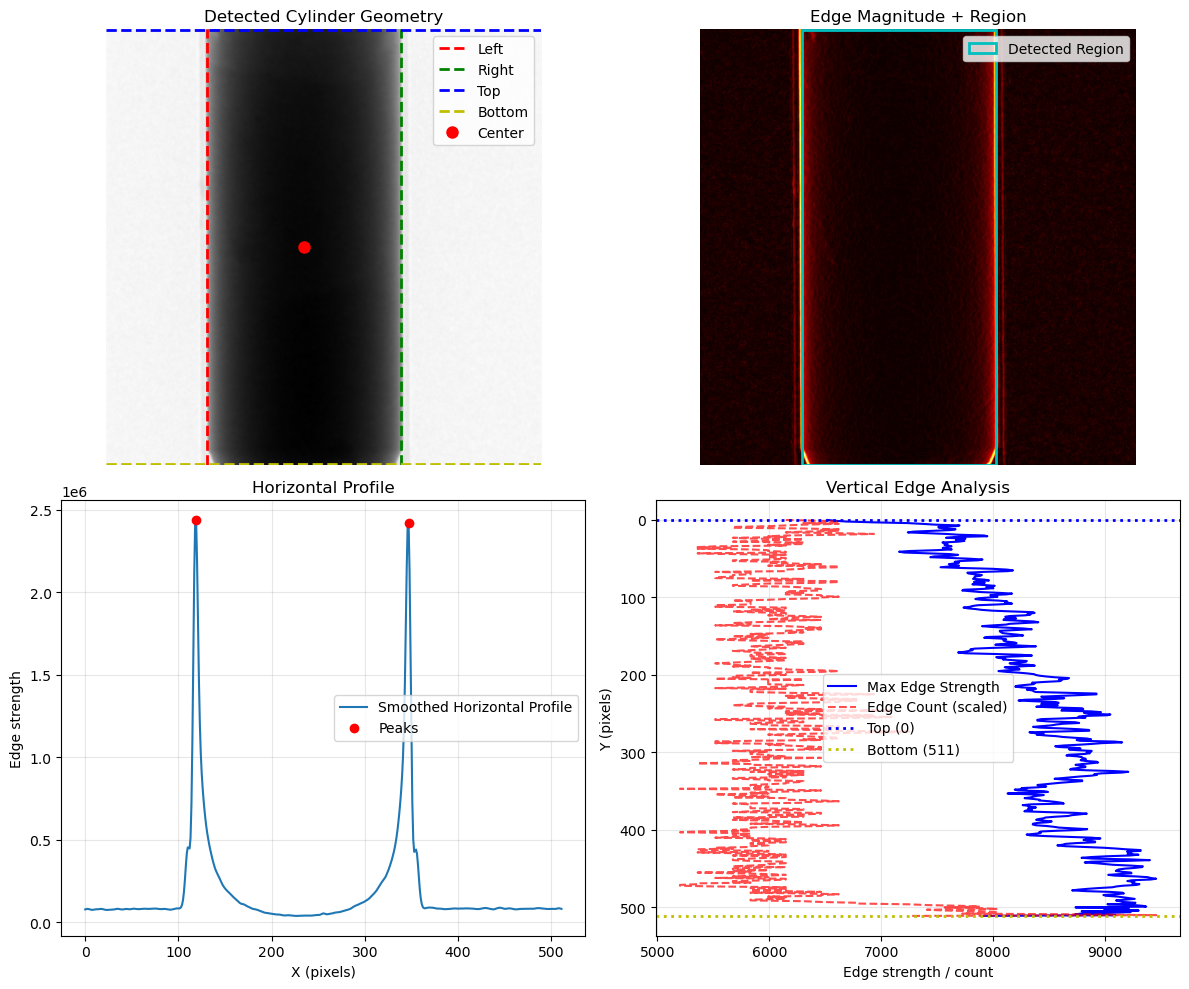

In [13]:
# check detection results
if diagnostics:
    show_detection(radiograph_summed, geometry, diagnostics)

### Compute Chord Length Map, $L(x)$

Using the geometry parameter detected, we will generate the chord length map, $L(x)$, by computing the distance from the center of the cylinder to the edges at each pixel position.

In [14]:
@dataclass(frozen=True, slots=True)
class ChordResult:
    # Vectorized chord length along x (same for all rows inside the cylinder’s vertical span)
    Lx: np.ndarray                 # shape: (width,)
    # 2D chord map (broadcasted along y only within cylinder vertical extent)
    chord_map: np.ndarray          # shape: (height, width)
    # Boolean mask where chord_map is valid (inside cylinder’s vertical span and |x-center_x|<=radius)
    mask: np.ndarray               # shape: (height, width)
    # Simple stats for quick logging
    stats: dict

In [15]:
def chord_length_profile_x(
    width: int,
    center_x: int,
    outer_radius: int,
    *,
    is_hollow: bool = False,
    inner_radius: Optional[int] = None,
    edge_epsilon: float = 0.0,
) -> np.ndarray:
    """
    Compute the 1D chord length profile L(x) for a vertical cylinder.

    For a solid cylinder:
        L(x) = 2 * sqrt(R^2 - (x - center_x)^2)   for |x - center_x| <= R
             = 0                                   otherwise

    For a hollow cylinder:
        L(x) = L_outer(x) - L_inner(x), clipped at >= 0

    Parameters
    ----------
    width : int
        Width of the image in pixels.
    center_x : int
        Horizontal coordinate of the cylinder center (in pixels).
    outer_radius : int
        Outer radius of the cylinder in pixels.
    is_hollow : bool, optional
        If True, compute profile for a hollow cylinder. Default is False.
    inner_radius : int, optional
        Inner radius (in pixels) for hollow cylinder. Ignored if
        `is_hollow` is False.
    edge_epsilon : float, optional
        Minimum chord length value to enforce for numerical stability.
        Values 0 < L < edge_epsilon are clipped to edge_epsilon.
        Useful only if the profile will be used in divisions. Default is 0.

    Returns
    -------
    L : ndarray of shape (width,)
        1D chord length profile across the image columns.
    """
    x = np.arange(width, dtype=np.float64)
    dx = x - float(center_x)

    outer_sq = np.maximum(0.0, float(outer_radius) ** 2 - dx**2)
    L_outer = 2.0 * np.sqrt(outer_sq)

    if not is_hollow:
        L = L_outer
    else:
        if inner_radius is None:
            raise ValueError("inner_radius must be provided when is_hollow=True")
        inner_sq = np.maximum(0.0, float(inner_radius) ** 2 - dx**2)
        L_inner = 2.0 * np.sqrt(inner_sq)
        L = np.maximum(0.0, L_outer - L_inner)

    if edge_epsilon > 0.0:
        small_pos = (L > 0.0) & (L < edge_epsilon)
        L = L.copy()
        L[small_pos] = edge_epsilon

    return L


def calculate_cylindrical_chord_map(
    image_shape: Tuple[int, int],
    *,
    center_x: int,
    top_edge: int,
    bottom_edge: int,
    radius: int,
    is_hollow: bool = False,
    inner_radius: Optional[int] = None,
    outside_fill: Literal["zero", "nan"] = "zero",
    edge_epsilon: float = 0.0,
) -> ChordResult:
    """
    Calculate the chord length profile and 2D map for a vertical cylinder.

    The chord length map represents the physical path length through the
    cylinder at each horizontal position. For an upright cylinder, the
    chord length depends only on `x`, and is broadcast vertically between
    `top_edge` and `bottom_edge`.

    Parameters
    ----------
    image_shape : tuple of int
        Shape of the image as (height, width).
    center_x : int
        Horizontal coordinate of the cylinder center (in pixels).
    top_edge : int
        Top edge (row index) of the cylinder bounding box.
    bottom_edge : int
        Bottom edge (row index) of the cylinder bounding box.
    radius : int
        Outer radius of the cylinder in pixels.
    is_hollow : bool, optional
        If True, compute chord lengths for a hollow cylinder. Default is False.
    inner_radius : int, optional
        Inner radius in pixels (used only if `is_hollow=True`).
    outside_fill : {"zero", "nan"}, optional
        Value assigned outside the cylinder region in the returned map.
        Default is "zero".
    edge_epsilon : float, optional
        Minimum chord length value to enforce for numerical stability.
        Useful if chord lengths will later appear in denominators.
        Default is 0.

    Returns
    -------
    result : ChordResult
        A dataclass with fields:

        - Lx : ndarray of shape (width,)
            1D chord length profile along the horizontal axis.
        - chord_map : ndarray of shape (height, width)
            2D chord length map with outside filled as 0 or NaN.
        - mask : ndarray of bool, shape (height, width)
            Boolean mask indicating valid cylinder pixels.
        - stats : dict
            Summary statistics (min, max, mean inside the cylinder, etc.).

    Notes
    -----
    - Outside the cylinder, the chord length is physically zero. Setting it to
      NaN (`outside_fill="nan"`) can be safer for debugging, as invalid regions
      will not contribute silently to calculations.
    - The `mask` should be used to restrict subsequent operations (e.g.,
      attenuation fitting or geometry correction) to valid pixels.
    """
    height, width = image_shape

    Lx = chord_length_profile_x(
        width=width,
        center_x=center_x,
        outer_radius=radius,
        is_hollow=is_hollow,
        inner_radius=inner_radius,
        edge_epsilon=edge_epsilon,
    )

    col_mask = Lx > 0.0
    row_mask = np.zeros(height, dtype=bool)
    row_mask[max(0, top_edge):min(height, bottom_edge + 1)] = True

    mask = np.outer(row_mask, col_mask)

    if outside_fill == "nan":
        chord_map = np.full((height, width), np.nan, dtype=np.float64)
    else:
        chord_map = np.zeros((height, width), dtype=np.float64)

    chord_map[row_mask, :] = Lx

    valid_vals = chord_map[mask]
    stats = {
        "shape": chord_map.shape,
        "valid_pixels": int(mask.sum()),
        "min_inside": float(np.nanmin(valid_vals)) if valid_vals.size else np.nan,
        "max_inside": float(np.nanmax(valid_vals)) if valid_vals.size else np.nan,
        "mean_inside": float(np.nanmean(valid_vals)) if valid_vals.size else np.nan,
        "radius": int(radius),
        "diameter": int(2 * radius),
        "type": "hollow" if is_hollow else "solid",
        "outside_fill": outside_fill,
    }

    return ChordResult(Lx=Lx, chord_map=chord_map, mask=mask, stats=stats)

In [16]:
res = calculate_cylindrical_chord_map(
    image_shape=radiograph_summed.shape,
    center_x=geometry.center_x,
    top_edge=geometry.top_edge,
    bottom_edge=geometry.bottom_edge,
    radius=geometry.radius,
    is_hollow=False,         # or True with inner_radius=...
    outside_fill="nan",      # or "zeros"
    edge_epsilon=0.0,        # usually 0 for Beer–Lambert workflows
)

pprint(res.stats)

{'diameter': 228,
 'max_inside': 228.0,
 'mean_inside': 179.80434117961423,
 'min_inside': 30.133038346638727,
 'outside_fill': 'nan',
 'radius': 114,
 'shape': (512, 512),
 'type': 'solid',
 'valid_pixels': 116224}


In [17]:
def show_chord_map(
    result: ChordResult,
    geometry,
    background: Optional[np.ndarray] = None,
    *,
    figsize: Tuple[int, int] = (14, 8),
) -> None:
    """
    Display the chord length map and related information.

    Layout
    ------
    Top row (2/3 height):
        - Detected geometry
        - 2D chord length map
        - Cylinder mask
    Bottom row (1/3 height):
        - Chord-length profile L(x) spanning full width

    Parameters
    ----------
    result : ChordResult
        The result object containing chord length data.
    geometry : object
        The geometry object containing cylinder parameters (must have
        center_x, center_y, radius, top_edge, bottom_edge).
    background : ndarray, optional
        Background image to display behind the chord map.
    figsize : tuple of int, optional
        Figure size for the plot. Default is (14, 8).
    """
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        2, 3, height_ratios=[2, 1], figure=fig
    )  # 2/3 vs 1/3 row height

    # --- Top row (3 plots) ---
    ax0 = fig.add_subplot(gs[0, 0])
    if background is not None:
        ax0.imshow(background, cmap="gray")
    else:
        ax0.imshow(np.zeros_like(result.chord_map), cmap="gray")
    ax0.axvline(geometry.center_x - geometry.radius, color="r", linestyle="--", label="Left")
    ax0.axvline(geometry.center_x + geometry.radius, color="g", linestyle="--", label="Right")
    ax0.axhline(geometry.top_edge, color="b", linestyle="--", label="Top")
    ax0.axhline(geometry.bottom_edge, color="y", linestyle="--", label="Bottom")
    ax0.plot(geometry.center_x, geometry.center_y, "ro", ms=6, label="Center")
    ax0.set_title("Detected Geometry")
    ax0.legend(loc="upper right")
    ax0.axis("off")

    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.imshow(result.chord_map, cmap="plasma")
    ax1.set_title("Chord length map")
    ax1.axis("off")
    fig.colorbar(im1, ax=ax1, shrink=0.7, label="Chord length (px)")

    ax2 = fig.add_subplot(gs[0, 2])
    ax2.imshow(result.mask, cmap="Greys")
    ax2.set_title("Cylinder mask")
    ax2.axis("off")

    # --- Bottom row (1 plot spanning all 3 columns) ---
    ax3 = fig.add_subplot(gs[1, :])  # span all 3 columns
    x = np.arange(result.Lx.size)
    ax3.plot(x, result.Lx, lw=2)
    ax3.set_xlabel("x (pixels)")
    ax3.set_ylabel("Chord length (pixels)")
    ax3.set_title("Chord-length profile L(x)")
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

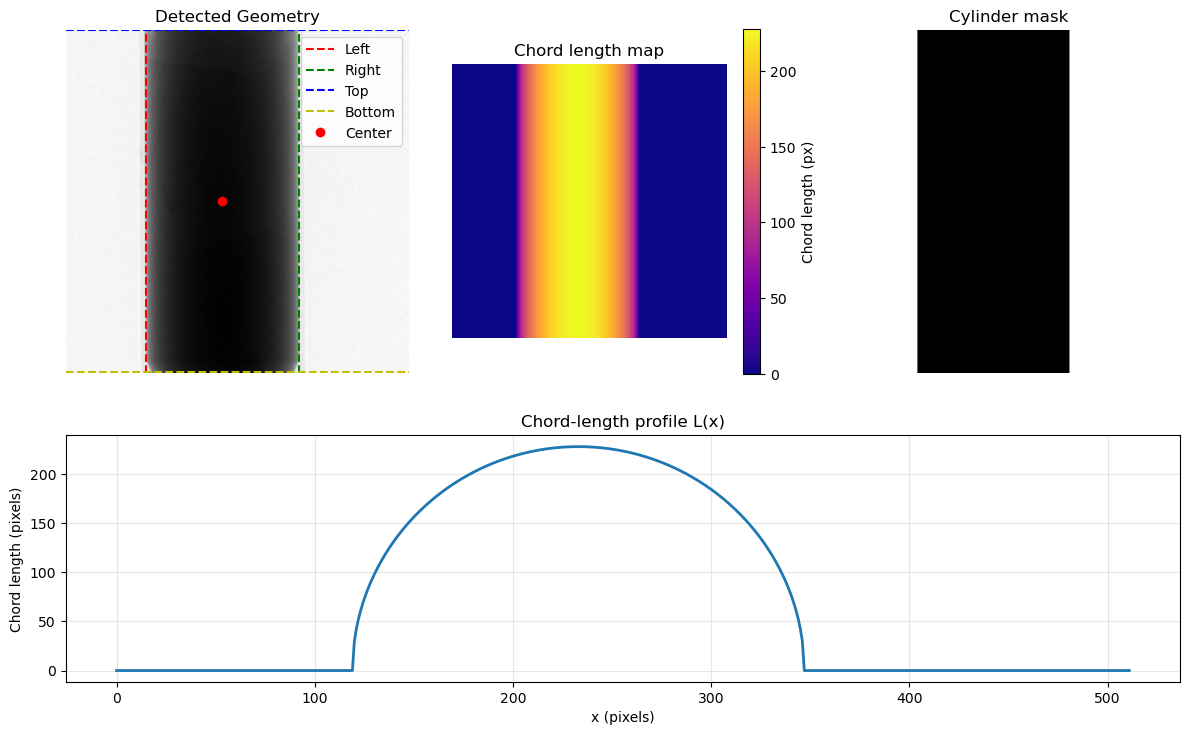

In [18]:
show_chord_map(
    res,
    geometry,
    background=radiograph_summed,
    figsize=(12, 8),
)

### Compute Correction Factor Map, $C(x, \lambda)$

Once the chord-length profile $L(x)$ is known, we can construct the correction factor that transforms the measured transmission into the equivalent case of a uniform thickness equal to the cylinder diameter $D$.
For each wavelength (TOF bin) $\lambda$, the correction factor is defined as

$$
C(x, \lambda) = \exp\bigl[-\mu(\lambda) \cdot (D - L(x))\bigr],
$$

where $\mu(\lambda)$ is the attenuation coefficient estimated from the transmission data.
Applying $C(x, \lambda)$ normalizes the cylindrical geometry effect, yielding data consistent with a flat slab of thickness $D$.

In [19]:
@dataclass(frozen=True)
class MuEstimationConfig:
    # Common
    exclude_edge_frac: float = 0.1     # drop columns where L(x) < frac * max(L)
    # Discrete (two-column, local-pairs)
    window: int = 7                    # half-width for local neighborhoods
    # Iterative (global fit with smooth baseline)
    baseline_order: int = 3            # polynomial order for b(x); 0=constant
    robust: bool = True                # Huber-like weighting toggle (simple)
    max_iter: int = 5                  # iterations for alternating fit

In [20]:
def estimate_mu(
    T_yxl: np.ndarray,
    Lx: np.ndarray,
    mask_yx: np.ndarray,
    method: Literal["discrete", "iterative"] = "discrete",
    *,
    cfg: Optional[MuEstimationConfig] = None,
) -> np.ndarray:
    """
    Estimate the wavelength-dependent attenuation coefficient μ(λ).

    Parameters
    ----------
    T_yxl : ndarray, shape (H, W, L)
        Transmission cube (per-wavelength/TOF). Values may exceed 1 due to OB issues.
    Lx : ndarray, shape (W,)
        Chord-length profile along x (pixels).
    mask_yx : ndarray of bool, shape (H, W)
        Cylinder support mask. Only pixels where mask=True are used.
    method : {"discrete", "iterative"}, optional
        - "discrete": two-column local-pairs median slope (your method).
        - "iterative": global slope + smooth baseline b(x) (alternating fit).
    cfg : MuEstimationConfig, optional
        Tunable parameters for each method.

    Returns
    -------
    mu_lambda : ndarray, shape (L,)
        Estimated μ(λ) for each wavelength bin.
    """
    if cfg is None:
        cfg = MuEstimationConfig()

    H, W, L = T_yxl.shape
    # Build a 1D in-cylinder mask over x using Lx and edge exclusion
    Lmax = float(np.nanmax(Lx))
    x_use = (Lx > cfg.exclude_edge_frac * Lmax)

    # Reduce over y using the cylinder mask → get a robust 1D profile in x
    # We take the masked geometric mean along y to reduce speckle:
    # y(x,λ) = -ln T̄(x,λ) with T̄ the masked geometric mean across y-rows.
    # Add tiny epsilon to avoid log(0).
    eps = 1e-12
    mask_rows = mask_yx.any(axis=1)
    # per x, collect y where mask True
    mu = np.zeros(L, dtype=np.float64)

    # Precompute per-x masked means across y for all λ
    # Shape: (W, L)
    Tbar_xl = np.full((W, L), np.nan, dtype=np.float64)
    for xi in range(W):
        if not x_use[xi]:
            continue
        row_sel = mask_yx[:, xi] & mask_rows
        if not np.any(row_sel):
            continue
        # geometric mean across rows: exp(mean(log(T+eps)))
        vals = T_yxl[row_sel, xi, :]  # shape (Ny, L)
        Tbar_xl[xi, :] = np.exp(np.nanmean(np.log(vals + eps), axis=0))

    # Valid x indices for regression
    valid_x = np.where(np.isfinite(Tbar_xl).all(axis=1) & x_use)[0]
    if valid_x.size < 2:
        raise ValueError("Not enough valid columns inside the cylinder to estimate μ(λ).")

    # Common transformation
    y_xl = -np.log(np.clip(Tbar_xl[valid_x, :], eps, None))  # shape: (Xv, L)
    L_vec = Lx[valid_x]                                      # shape: (Xv,)

    if method == "discrete":
        mu = _estimate_mu_discrete(y_xl, L_vec, window=cfg.window)
    elif method == "iterative":
        mu = _estimate_mu_iterative(
            y_xl, L_vec,
            baseline_order=cfg.baseline_order,
            robust=cfg.robust,
            max_iter=cfg.max_iter,
        )
    else:
        raise ValueError(f"Unknown method: {method}")

    # Enforce physical non-negativity
    mu = np.maximum(0.0, mu)
    return mu


def _estimate_mu_discrete(
    y_xl: np.ndarray,
    L_vec: np.ndarray,
    *,
    window: int,
) -> np.ndarray:
    """
    Discrete (two-column, local-pairs) estimator.
    For each λ, compute local pairwise slopes (y_i - y_j)/(L_i - L_j) within +/- window,
    then take the median across pairs and positions.
    """
    Xv, L = y_xl.shape
    mu = np.zeros(L, dtype=np.float64)

    for k in range(L):
        yx = y_xl[:, k]
        slopes = []
        for i in range(Xv):
            j0 = max(0, i - window)
            j1 = min(Xv, i + window + 1)
            Li = L_vec[i]
            yi = yx[i]
            Lj = L_vec[j0:j1]
            yj = yx[j0:j1]
            dL = Lj - Li
            sel = np.abs(dL) > 0
            if np.any(sel):
                slopes.extend(((yj[sel] - yi) / dL[sel]).tolist())
        if slopes:
            mu[k] = np.median(slopes)
        else:
            mu[k] = 0.0
    return mu


def _estimate_mu_iterative(
    y_xl: np.ndarray,
    L_vec: np.ndarray,
    *,
    baseline_order: int,
    robust: bool,
    max_iter: int,
) -> np.ndarray:
    """
    Iterative global estimator:
    minimize  y(x,λ) ≈ μ(λ) * L(x) + b_λ(x),  with b_λ(x) a low-order polynomial in x.
    Alternating steps: (1) fit μ given b, (2) fit b given μ. Optionally robust-weighted.
    """
    Xv, L = y_xl.shape
    # Normalize x-grid for numerical stability in polynomial fit
    xv = np.linspace(-1.0, 1.0, Xv)
    Phi = np.vstack([xv**p for p in range(baseline_order + 1)]).T  # (Xv, P)
    P = Phi.shape[1]

    mu = np.zeros(L, dtype=np.float64)
    # Initialize baseline and weights
    b_xl = np.zeros_like(y_xl)     # baseline per (x,λ)
    W_xl = np.ones_like(y_xl)      # weights for robust fitting

    for _ in range(max_iter):
        # Step 1: fit μ(λ) via weighted least squares over x
        # y ≈ μ L + b  => μ = argmin Σ_x w (y - b - μL)^2
        # closed-form per λ:
        num = np.sum(W_xl * L_vec[:, None] * (y_xl - b_xl), axis=0)
        den = np.sum(W_xl * (L_vec[:, None]**2), axis=0) + 1e-12
        mu = num / den
        mu = np.maximum(0.0, mu)

        # Step 2: fit b_λ(x) as poly(x) to residuals r = y - μL
        r_xl = y_xl - (L_vec[:, None] * mu[None, :])
        # Per λ polynomial regression in closed form
        # b(·,λ) = Phi * beta_λ ; beta_λ = (Phi^T Phi)^-1 Phi^T r_·λ
        G = np.linalg.pinv(Phi)   # (P, Xv)
        beta_l = G @ r_xl         # (P, L)
        b_xl = Phi @ beta_l       # (Xv, L)

        # Optional robust weights (Huber-like)
        if robust:
            resid = y_xl - (L_vec[:, None] * mu[None, :]) - b_xl
            s = 1.4826 * np.median(np.abs(resid), axis=0) + 1e-12
            z = resid / s[None, :]
            W_xl = 1.0 / (1.0 + z**2)  # smooth Tukey-like; bounded influence

    return mu

In [21]:
def build_correction_factor_map(
    Lx: np.ndarray,
    mu_lambda: np.ndarray,
    D: float,
) -> np.ndarray:
    """
    Construct C(x,λ) = exp(-μ(λ) * (D - L(x))) without allocating huge temporaries.

    Parameters
    ----------
    Lx : ndarray, shape (W,)
        Chord-length profile across x.
    mu_lambda : ndarray, shape (L,)
        Estimated attenuation coefficients per wavelength.
    D : float
        Target uniform thickness (diameter) in pixel units.

    Returns
    -------
    C_xl : ndarray, shape (W, L)
        Correction factor map over (x, λ).
    """
    # (W,1) and (1,L) broadcasting → (W,L)
    return np.exp(-(D - Lx[:, None]) * mu_lambda[None, :])

In [22]:
def compute_correction(
    T_yxl: np.ndarray,
    Lx: np.ndarray,
    mask_yx: np.ndarray,
    D: float,
    method: Literal["discrete", "iterative"] = "discrete",
    *,
    cfg: Optional[MuEstimationConfig] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convenience: estimate μ(λ) with the chosen method and return (μ(λ), C(x,λ)).

    Returns
    -------
    mu_lambda : ndarray, shape (L,)
    C_xl : ndarray, shape (W, L)
    """
    mu_lambda = estimate_mu(T_yxl, Lx, mask_yx, method=method, cfg=cfg)
    C_xl = build_correction_factor_map(Lx, mu_lambda, D)
    return mu_lambda, C_xl

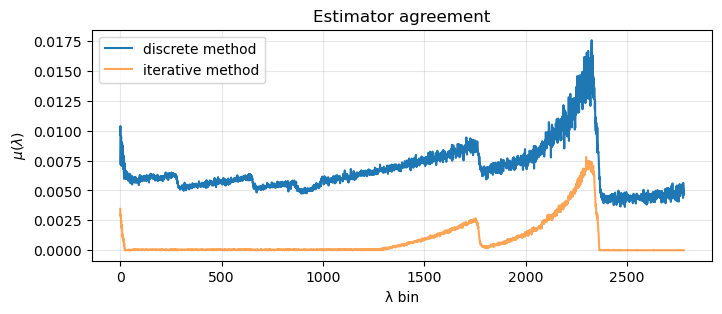

In [23]:
# Compute the correction factors
mu_config = MuEstimationConfig(
  window=9,  # larger window size leads to smoother discrete estimates
)
# Discrete method
mu_disc, C_disc = compute_correction(
  T_yxl=hyperspectral_stack,
  Lx=res.Lx,
  mask_yx=res.mask,
  D=geometry.right_edge - geometry.left_edge,
  method="discrete",
  cfg=mu_config
)
# Iterative method
mu_iter, C_iter = compute_correction(
  T_yxl=hyperspectral_stack,
  Lx=res.Lx,
  mask_yx=res.mask,
  D=geometry.right_edge - geometry.left_edge,
  method="iterative",
  cfg=mu_config
)
plt.figure(figsize=(8,3))
plt.plot(mu_disc, label="discrete method")
plt.plot(mu_iter, label="iterative method", alpha=0.7)
plt.xlabel("λ bin"); plt.ylabel(r"$\mu(\lambda)$"); plt.title("Estimator agreement")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")

### Apply Correction to Transmission Data

With the correction factor map $C(x, \lambda)$ available, we can normalize the measured transmission $T(y, x, \lambda)$ to remove the cylindrical geometry effect.
The corrected transmission is obtained as

$$
T_{\text{corr}}(y, x, \lambda) := T(y, x, \lambda) \cdot C(x, \lambda).
$$

This operation adjusts each pixel and wavelength to be consistent with a uniform slab of thickness $D$, enabling quantitative analysis without geometry-induced bias.

In [24]:
def apply_cylindrical_correction(
    T_yxl: np.ndarray,
    C_xl: np.ndarray,
    mask_yx: np.ndarray,
    *,
    copy: bool = True,
) -> np.ndarray:
    """
    Apply cylindrical geometry correction to a hyperspectral transmission cube.

    The correction is applied as:
        T_corr(y, x, λ) := T(y, x, λ) * C(x, λ)
    for pixels inside `mask_yx`. Pixels outside the mask are left unchanged.

    Parameters
    ----------
    T_yxl : ndarray, shape (H, W, L)
        Input transmission data (may contain values > 1 due to OB issues).
    C_xl : ndarray, shape (W, L)
        Correction factor map over (x, λ). Typically C(x, λ) = exp[-μ(λ) (D - L(x))].
    mask_yx : ndarray of bool, shape (H, W)
        Cylinder support mask (True where the sample exists and correction should apply).
    copy : bool, optional
        If True, operate on a copy and return it. If False, correct in-place.
        Default is True.

    Returns
    -------
    Tcorr_yxl : ndarray, shape (H, W, L)
        Corrected transmission cube.

    Notes
    -----
    - This function avoids allocating a full (H, W, L) correction cube by
      applying C(x, λ) row-by-row only on columns where `mask_yx` is True.
    - Outside the mask, data are left as-is so downstream code can keep using
      the original background if needed.
    """
    if T_yxl.ndim != 3:
        raise ValueError(f"`T_yxl` must be 3D (H,W,L), got shape {T_yxl.shape}.")
    H, W, L = T_yxl.shape
    if C_xl.shape != (W, L):
        raise ValueError(f"`C_xl` must have shape (W,L)={(W,L)}, got {C_xl.shape}.")
    if mask_yx.shape != (H, W):
        raise ValueError(f"`mask_yx` must have shape (H,W)={(H,W)}, got {mask_yx.shape}.")

    Tcorr = T_yxl.copy() if copy else T_yxl

    # Apply per row to avoid huge broadcasts; only touch masked columns
    rows = np.where(mask_yx.any(axis=1))[0]
    for y in rows:
        xmask = mask_yx[y, :]
        if np.any(xmask):
            # Multiply only the columns inside the cylinder for all λ
            # shapes: Tcorr[y, xmask, :] (Nx, L) *= C_xl[xmask, :] (Nx, L)
            Tcorr[y, xmask, :] *= C_xl[xmask, :]

    return Tcorr

In [25]:
def visualize_correction(
    T_yxl: np.ndarray,
    Tcorr_yxl: np.ndarray,
    mask_yx: np.ndarray,
    *,
    lambda_indices: Optional[Sequence[int]] = None,
    figsize: Tuple[int, int] = (14, 8),
) -> None:
    """
    Visualize before/after correction with improved diagnostics.

    Top row (2/3 height)
    --------------------
    - Before:  heatmap of  A(x,λ) = -ln( T̄(x,λ) )
    - After:   heatmap of  A^D(x,λ) = -ln( T̄^D(x,λ) )
    - Diff:    (After - Before) with diverging colormap centered at 0

    Bottom row (1/3 height)
    -----------------------
    - x-profiles at selected λ bins:
        * color encodes λ index
        * linestyle encodes before (solid) vs after (dashed)

    Notes
    -----
    - T̄ is the geometric mean across y within the cylinder mask.
    - Air (columns outside cylinder support) are shown in light gray.
    """
    if T_yxl.shape != Tcorr_yxl.shape:
        raise ValueError("`T_yxl` and `Tcorr_yxl` must have the same shape.")
    if mask_yx.shape != T_yxl.shape[:2]:
        raise ValueError("`mask_yx` must match the first two dims of T.")
    H, W, L = T_yxl.shape

    # Choose λ bins for profile plots
    if lambda_indices is None:
        lambda_indices = [int(0.1 * L), int(0.5 * L), int(0.9 * L)]
    lambda_indices = [i for i in lambda_indices if 0 <= i < L]
    if not lambda_indices:
        raise ValueError("No valid `lambda_indices` to plot.")

    # Geometric mean across y (masked) -> (W, L)
    eps = 1e-12
    rows = np.where(mask_yx.any(axis=1))[0]
    if rows.size == 0:
        raise ValueError("Mask has no valid rows.")
    T_sub = T_yxl[rows, :, :]
    Tc_sub = Tcorr_yxl[rows, :, :]
    M_sub = mask_yx[rows, :]

    Tbar_xl = np.full((W, L), np.nan, dtype=np.float64)
    Tbar_corr_xl = np.full((W, L), np.nan, dtype=np.float64)

    # column-wise (x) masking
    xmask = M_sub.any(axis=0)  # True for x within cylinder vertically

    for x in np.where(xmask)[0]:
        ymask = M_sub[:, x]
        # geometric means over y
        Tbar_xl[x, :] = np.exp(np.nanmean(np.log(np.clip(T_sub[ymask, x, :], eps, None)), axis=0))
        Tbar_corr_xl[x, :] = np.exp(np.nanmean(np.log(np.clip(Tc_sub[ymask, x, :], eps, None)), axis=0))

    A_before = -np.log(np.clip(Tbar_xl, eps, None))       # (W, L)
    A_after  = -np.log(np.clip(Tbar_corr_xl, eps, None))  # (W, L)
    A_delta  = A_after - A_before

    # Colormaps: set 'bad' (NaN) → light gray for air/out-of-ROI
    cmap_seq = plt.cm.viridis.copy()
    cmap_seq.set_bad(color="lightgray")
    cmap_div = plt.cm.bwr.copy()
    cmap_div.set_bad(color="lightgray")

    # Zero-centered normalization for the difference panel
    # Use symmetric limits based on finite values
    finite_delta = np.isfinite(A_delta)
    if np.any(finite_delta):
        vmax = np.nanpercentile(np.abs(A_delta[finite_delta]), 98.0)
        norm_div = colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)
    else:
        norm_div = colors.TwoSlopeNorm(vcenter=0.0, vmin=-1.0, vmax=1.0)

    # Layout
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 3, height_ratios=[2, 1], figure=fig)

    # Top row: heatmaps
    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.imshow(np.ma.masked_invalid(A_before), aspect='auto', cmap=cmap_seq)
    ax0.set_title(r"Before: $-\ln \bar{T}(x,\lambda)$")
    ax0.set_xlabel("λ bin")
    ax0.set_ylabel("x")
    fig.colorbar(im0, ax=ax0, shrink=0.8)

    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.imshow(np.ma.masked_invalid(A_after), aspect='auto', cmap=cmap_seq)
    ax1.set_title(r"After: $-\ln \bar{T}^D(x,\lambda)$")
    ax1.set_xlabel("λ bin")
    ax1.set_ylabel("x")
    fig.colorbar(im1, ax=ax1, shrink=0.8)

    ax2 = fig.add_subplot(gs[0, 2])
    im2 = ax2.imshow(np.ma.masked_invalid(A_delta), aspect='auto', cmap=cmap_div, norm=norm_div)
    ax2.set_title(r"Difference: After − Before")
    ax2.set_xlabel("λ bin")
    ax2.set_ylabel("x")
    fig.colorbar(im2, ax=ax2, shrink=0.8)

    # Annotate air region in the top panels (optional but clarifying)
    # We'll draw semi-transparent bands where xmask is False
    air_rows = np.where(~xmask)[0]
    if air_rows.size:
        for ax in (ax0, ax1, ax2):
            for r in air_rows:
                ax.axhspan(r-0.5, r+0.5, color="lightgray", alpha=0.15, lw=0)

    # Bottom row: x-profiles — color=λ, linestyle=before/after
    ax3 = fig.add_subplot(gs[1, :])
    xgrid = np.arange(W)
    # color map for chosen λs
    palette = plt.cm.tab10(np.linspace(0, 1, max(3, len(lambda_indices))))
    for idx, li in enumerate(lambda_indices):
        col = palette[idx]
        # Use masked arrays so air columns plot as gaps
        Tb = np.ma.masked_where(~xmask, Tbar_xl[:, li])
        Ta = np.ma.masked_where(~xmask, Tbar_corr_xl[:, li])
        ax3.plot(xgrid, Tb, color=col, linestyle='-', label=f"λ={li} (before)")
        ax3.plot(xgrid, Ta, color=col, linestyle='--', label=f"λ={li} (after)")
    ax3.set_xlabel("x (pixels)")
    ax3.set_ylabel(r"$\bar{T}(x,\lambda)$")
    ax3.set_title("x-profiles at selected λ bins")
    ax3.grid(True, alpha=0.3)
    ax3.legend(ncol=min(3, 2*len(lambda_indices)))

    plt.tight_layout()
    plt.show()

    # Quantitative flatness summary (unchanged)
    if np.any(xmask):
        def cov_across_x(A):
            m = np.nanmean(A[xmask, :], axis=0)
            s = np.nanstd(A[xmask, :], axis=0)
            return s / np.maximum(m, 1e-12)
        cov_b = cov_across_x(A_before)
        cov_a = cov_across_x(A_after)
        print(f"Flatness CoV across x — median over λ: before={np.nanmedian(cov_b):.4g}, after={np.nanmedian(cov_a):.4g}")

In [26]:
Tcorr = apply_cylindrical_correction(
    T_yxl=hyperspectral_stack,
    C_xl=C_disc,
    mask_yx=res.mask,
    copy=True,  # keep original untouched
)

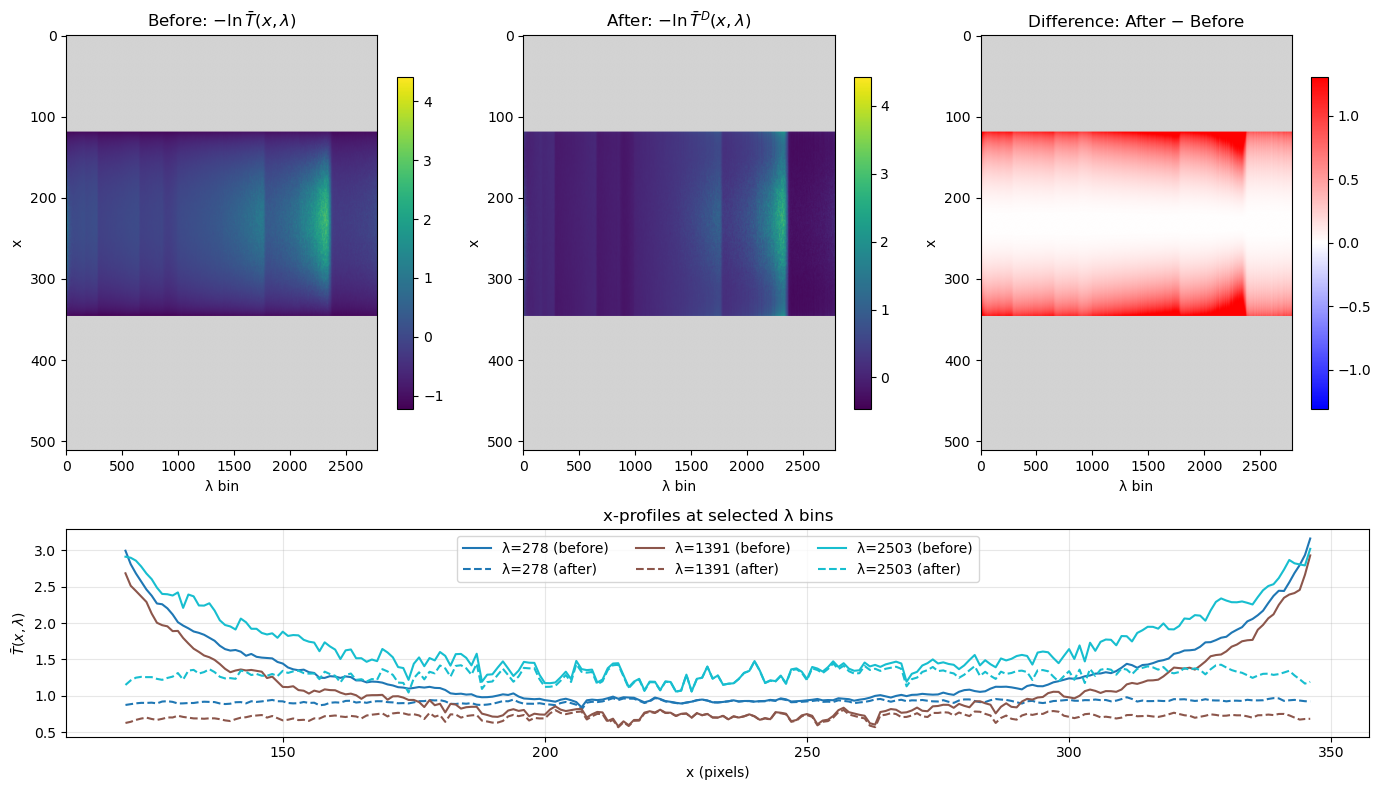

Flatness CoV across x — median over λ: before=2.716e+11, after=0.4228


In [27]:
visualize_correction(
    T_yxl=hyperspectral_stack,
    Tcorr_yxl=Tcorr,
    mask_yx=res.mask,
    lambda_indices=[int(0.1*mu_disc.size), int(0.5*mu_disc.size), int(0.9*mu_disc.size)],
)

In [28]:
def analyze_hyperspectral_comparison(
    T_yxl_before: np.ndarray,
    T_yxl_after: Optional[np.ndarray] = None,
    *,
    mask_yx: Optional[np.ndarray] = None,
    title_prefix: str = "Hyperspectral",
    n_intensity_bins: int = 100,
    selected_channels_count: int = 5,
    selected_channels: Optional[Sequence[int]] = None,
    figsize: Tuple[int, int] = (16, 7),
    percentile_clip: float = 99.5,
    show_plots: bool = True,
    show_statistics: bool = True,
) -> Dict[str, Any]:
    """
    Analyze hyperspectral transmission data (before and optional after correction).

    This function computes 2D histograms of Log10(intensity) vs TOF channel, basic and
    per-channel statistics, and (if `T_yxl_after` is provided) side-by-side comparisons
    with a difference panel. It supports restricting the analysis to a region-of-interest
    via `mask_yx`.

    Parameters
    ----------
    T_yxl_before : ndarray, shape (H, W, L)
        Original hyperspectral transmission cube.
    T_yxl_after : ndarray, shape (H, W, L), optional
        Corrected hyperspectral cube to compare against the original.
    mask_yx : ndarray of bool, shape (H, W), optional
        If provided, analysis is restricted to pixels where mask is True.
    title_prefix : str, optional
        Prefix for plot titles. Default is "Hyperspectral".
    n_intensity_bins : int, optional
        Number of intensity bins in the (log-scaled) 2D histogram. Default is 100.
    selected_channels_count : int, optional
        Number of channels to include in the bottom histograms if `selected_channels` is None.
        Default is 5.
    selected_channels : sequence of int, optional
        Explicit list of TOF channel indices to show in the bottom histograms.
        Overrides `selected_channels_count` if provided.
    figsize : tuple of int, optional
        Matplotlib figure size. Default is (16, 7).
    percentile_clip : float, optional
        Upper percentile used to clip outliers in per-channel hist visualization.
        Default is 99.5.
    show_plots : bool, optional
        If True, render plots. Default is True.
    show_statistics : bool, optional
        If True, print summary statistics. Default is True.

    Returns
    -------
    results : dict
        Dictionary containing:
        - 'basic_stats_before' : dict of global stats for T_yxl_before
        - 'basic_stats_after'  : dict of global stats for T_yxl_after (if provided)
        - 'value_distribution_before' : dict with counts and percentages for ranges
        - 'value_distribution_after'  : dict (if provided)
        - 'hist_2d_before' : ndarray (n_bins-1, L) 2D histogram for before
        - 'hist_2d_after'  : ndarray (n_bins-1, L) 2D histogram for after (if provided)
        - 'channel_stats_df_before' : pd.DataFrame per-channel stats (before)
        - 'channel_stats_df_after'  : pd.DataFrame per-channel stats (after, if provided)
        - 'log_intensity_bins' : 1D ndarray of intensity bin edges (shared for before/after)
        - 'min_positive_val' : float intensity lower bound used
        - 'max_val' : float intensity upper bound used
    """
    # ---------- helpers ----------
    def _flatten_data(T, M):
        if M is None:
            return T.reshape(-1)
        return T[M].reshape(-1)

    def _per_channel_iter(T, M):
        H, W, L = T.shape
        for ch in range(L):
            if M is None:
                yield ch, T[:, :, ch].reshape(-1)
            else:
                yield ch, T[:, :, ch][M].reshape(-1)

    def _basic_and_distribution(flat):
        total_pixels = flat.size
        min_val = float(np.nanmin(flat))
        max_val = float(np.nanmax(flat))
        mean_val = float(np.nanmean(flat))
        median_val = float(np.nanmedian(flat))
        count_normal = int(np.sum((flat >= 0) & (flat <= 1)))
        count_above_1 = int(np.sum(flat > 1))
        count_negative = int(np.sum(flat < 0))
        return (
            {
                'min_value': min_val,
                'max_value': max_val,
                'mean_value': mean_val,
                'median_value': median_val,
                'total_pixels': total_pixels,
            },
            {
                'normal_count': count_normal,
                'above_1_count': count_above_1,
                'negative_count': count_negative,
                'total_pixels': total_pixels,
                'normal_percentage': 100.0 * count_normal / max(total_pixels, 1),
                'above_1_percentage': 100.0 * count_above_1 / max(total_pixels, 1),
                'negative_percentage': 100.0 * count_negative / max(total_pixels, 1),
            },
        )

    def _per_channel_stats(T, M):
        recs = []
        for ch, vec in _per_channel_iter(T, M):
            recs.append({
                'channel': ch,
                'min_val': float(np.nanmin(vec)),
                'max_val': float(np.nanmax(vec)),
                'mean_val': float(np.nanmean(vec)),
                'median_val': float(np.nanmedian(vec)),
                'std_val': float(np.nanstd(vec)),
                'above_1_count': int(np.sum(vec > 1)),
                'above_1_percentage': float(100.0 * np.sum(vec > 1) / max(vec.size, 1)),
                'negative_count': int(np.sum(vec < 0)),
                'zero_count': int(np.sum(vec == 0)),
            })
        return pd.DataFrame.from_records(recs)

    def _2d_histogram_log(T, M, log_bins):
        H, W, L = T.shape
        hist = np.zeros((log_bins.size - 1, L), dtype=np.float64)
        Tlog = np.log10(np.clip(T, min_positive_val, None))
        for ch in range(L):
            vec = Tlog[:, :, ch].reshape(-1) if M is None else Tlog[:, :, ch][M].reshape(-1)
            h, _ = np.histogram(vec, bins=log_bins)
            hist[:, ch] = h
        return hist

    # ---------- inputs & shared bins ----------
    if T_yxl_before.ndim != 3:
        raise ValueError("T_yxl_before must be 3D (H,W,L).")
    if T_yxl_after is not None and T_yxl_after.shape != T_yxl_before.shape:
        raise ValueError("T_yxl_after must match T_yxl_before shape.")

    H, W, L = T_yxl_before.shape
    if mask_yx is not None and mask_yx.shape != (H, W):
        raise ValueError("mask_yx must have shape (H, W).")

    # Flattened views
    flat_before = _flatten_data(T_yxl_before, mask_yx)
    if T_yxl_after is not None:
        flat_after = _flatten_data(T_yxl_after, mask_yx)

    # Shared intensity binning across before/after for fair comparison
    # Use positive values only to define the lower bound for log bins
    pos_before = flat_before[flat_before > 0]
    if pos_before.size == 0:
        raise ValueError("No positive values in 'before' data to define log bins.")

    if T_yxl_after is None:
        min_positive_val = float(np.nanmin(pos_before))
        max_val = float(np.nanmax(flat_before))
    else:
        pos_after = flat_after[flat_after > 0]
        if pos_after.size == 0:
            raise ValueError("No positive values in 'after' data to define log bins.")
        min_positive_val = float(np.nanmin([np.nanmin(pos_before), np.nanmin(pos_after)]))
        max_val = float(np.nanmax([np.nanmax(flat_before), np.nanmax(flat_after)]))

    # Log-spaced intensity bins and corresponding log bins
    log_intensity_bins = np.logspace(np.log10(min_positive_val), np.log10(max_val), n_intensity_bins)
    log_bins = np.log10(log_intensity_bins)

    # ---------- stats ----------
    basic_before, dist_before = _basic_and_distribution(flat_before)
    df_before = _per_channel_stats(T_yxl_before, mask_yx)
    hist_before = _2d_histogram_log(T_yxl_before, mask_yx, log_bins)

    if T_yxl_after is not None:
        basic_after, dist_after = _basic_and_distribution(flat_after)
        df_after = _per_channel_stats(T_yxl_after, mask_yx)
        hist_after = _2d_histogram_log(T_yxl_after, mask_yx, log_bins)
        hist_diff = hist_after - hist_before
    else:
        basic_after = dist_after = df_after = hist_after = hist_diff = None

    # ---------- reporting ----------
    if show_statistics:
        print(f"{title_prefix} (scope: {'masked ROI' if mask_yx is not None else 'full image'})")
        print(f"Cube shape: {T_yxl_before.shape}, dtype: {T_yxl_before.dtype}")
        print(f"Log-binning intensity range: [{min_positive_val:.3g}, {max_val:.3g}]")
        print("\nBefore (original) — basic stats:")
        print(pd.Series(basic_before).to_string())
        print("\nBefore (original) — value distribution:")
        print(pd.Series(dist_before).round(3).to_string())

        if T_yxl_after is not None:
            print("\nAfter (corrected) — basic stats:")
            print(pd.Series(basic_after).to_string())
            print("\nAfter (corrected) — value distribution:")
            print(pd.Series(dist_after).round(3).to_string())

            # Quick improvement signal: fraction > 1 per channel
            frac_before = df_before['above_1_count'] / (mask_yx.sum() if mask_yx is not None else (H*W))
            frac_after  = df_after['above_1_count']  / (mask_yx.sum() if mask_yx is not None else (H*W))
            print("\nChannels with >1 values (fraction):")
            print(f"  median before={np.nanmedian(frac_before):.4%}, after={np.nanmedian(frac_after):.4%}")

    # ---------- plots ----------
    if show_plots:
        if T_yxl_after is None:
            # Simple 1x2: 2D hist + selected-channel histograms
            fig, axes = plt.subplots(1, 2, figsize=figsize)
            im = axes[0].imshow(
                hist_before,
                aspect='auto', origin='lower', cmap='viridis',
                extent=[0, L-1, np.log10(min_positive_val), np.log10(max_val)]
            )
            axes[0].set_xlabel('TOF Channel')
            axes[0].set_ylabel('Log10(Intensity)')
            axes[0].set_title(f'{title_prefix}: 2D Histogram (Before)')
            axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='log10(1)=0')
            axes[0].legend()
            plt.colorbar(im, ax=axes[0], label='Pixel Count')
            _plot_selected_channel_histograms(
                axes[1],
                cube=T_yxl_before,
                mask=mask_yx,
                selected_channels=selected_channels,
                selected_channels_count=selected_channels_count,
                percentile_clip=percentile_clip,
                title=f'{title_prefix}: Intensity Distributions (Before)'
            )
            plt.tight_layout()
            plt.show()
        else:
            # -------- three-row layout --------
            fig = plt.figure(figsize=figsize)
            gs = gridspec.GridSpec(
                3, 3, height_ratios=[2, 1.2, 1.6], figure=fig
            )

            # Row 1: 2D histograms (before / after / diff)
            ax0 = fig.add_subplot(gs[0, 0])
            im0 = ax0.imshow(
                hist_before, aspect='auto', origin='lower', cmap='viridis',
                extent=[0, L-1, np.log10(min_positive_val), np.log10(max_val)]
            )
            ax0.set_title(f'{title_prefix}: 2D Hist (Before)')
            ax0.set_xlabel('TOF Channel'); ax0.set_ylabel('Log10(Intensity)')
            ax0.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
            fig.colorbar(im0, ax=ax0, shrink=0.8, label='Pixel Count')

            ax1 = fig.add_subplot(gs[0, 1])
            im1 = ax1.imshow(
                hist_after, aspect='auto', origin='lower', cmap='viridis',
                extent=[0, L-1, np.log10(min_positive_val), np.log10(max_val)]
            )
            ax1.set_title(f'{title_prefix}: 2D Hist (After)')
            ax1.set_xlabel('TOF Channel'); ax1.set_ylabel('Log10(Intensity)')
            ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
            fig.colorbar(im1, ax=ax1, shrink=0.8, label='Pixel Count')

            ax2 = fig.add_subplot(gs[0, 2])
            vmax = np.nanpercentile(np.abs(hist_diff), 99.0)
            im2 = ax2.imshow(
                hist_diff, aspect='auto', origin='lower',
                cmap='bwr', norm=colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax),
                extent=[0, L-1, np.log10(min_positive_val), np.log10(max_val)]
            )
            ax2.set_title('Difference: After − Before')
            ax2.set_xlabel('TOF Channel'); ax2.set_ylabel('Log10(Intensity)')
            fig.colorbar(im2, ax=ax2, shrink=0.8, label='Δ Pixel Count')

            # Row 2: Fraction > 1 per channel (before vs after)
            ax3 = fig.add_subplot(gs[1, :])
            frac_b = df_before['above_1_count'] / (mask_yx.sum() if mask_yx is not None else (H*W))
            frac_a = df_after['above_1_count']  / (mask_yx.sum() if mask_yx is not None else (H*W))
            ax3.plot(frac_b.values, label='before', linestyle='-')
            ax3.plot(frac_a.values, label='after', linestyle='--')
            ax3.set_xlabel('TOF Channel'); ax3.set_ylabel('Fraction > 1')
            ax3.set_title('Fraction of Pixels above 1 (per Channel)')
            ax3.grid(True, alpha=0.3); ax3.legend()

            # Row 3: Distributions per selected channels (legend outside)
            ax4 = fig.add_subplot(gs[2, :])
            # before
            _plot_selected_channel_histograms(
                ax4,
                cube=T_yxl_before, mask=mask_yx,
                selected_channels=selected_channels,
                selected_channels_count=selected_channels_count,
                percentile_clip=percentile_clip,
                title='Distributions per Channel (Before vs After)',
                style='solid'
            )
            # after (overlay, same colors; dashed linestyle rendered by helper)
            _plot_selected_channel_histograms(
                ax4,
                cube=T_yxl_after, mask=mask_yx,
                selected_channels=selected_channels,
                selected_channels_count=selected_channels_count,
                percentile_clip=percentile_clip,
                title='Distributions per Channel (Before vs After)',
                style='dashed'
            )
            ax4.axvline(x=1, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
            ax4.set_yscale('log')
            # push legend outside to the right
            leg = ax4.legend(
                ncol=1, frameon=True, fontsize='small',
                loc='center left', bbox_to_anchor=(1.01, 0.5), borderaxespad=1.0
            )
            # make room for the outside legend
            plt.subplots_adjust(right=0.82)

            plt.tight_layout()
            plt.show()

    # ---------- return ----------
    results = {
        'basic_stats_before': basic_before,
        'value_distribution_before': dist_before,
        'hist_2d_before': hist_before,
        'channel_stats_df_before': df_before,
        'log_intensity_bins': log_intensity_bins,
        'min_positive_val': min_positive_val,
        'max_val': max_val,
    }
    if T_yxl_after is not None:
        results.update({
            'basic_stats_after': basic_after,
            'value_distribution_after': dist_after,
            'hist_2d_after': hist_after,
            'hist_2d_diff': hist_diff,
            'channel_stats_df_after': df_after,
        })
    return results


def _plot_selected_channel_histograms(
    ax: plt.Axes,
    *,
    cube: np.ndarray,
    mask: Optional[np.ndarray],
    selected_channels: Optional[Sequence[int]],
    selected_channels_count: int,
    percentile_clip: float,
    title: str,
    style: str = 'solid',
) -> None:
    """Internal: overlay histograms for selected channels on a given Axes."""
    H, W, L = cube.shape
    if selected_channels is None:
        channels = np.linspace(0, L-1, selected_channels_count, dtype=int)
    else:
        channels = [ch for ch in selected_channels if 0 <= ch < L]
        if not channels:
            channels = np.linspace(0, L-1, selected_channels_count, dtype=int)

    palette = plt.cm.tab10(np.linspace(0, 1, max(3, len(channels))))
    for i, ch in enumerate(channels):
        vec = cube[:, :, ch].reshape(-1) if mask is None else cube[:, :, ch][mask].reshape(-1)
        # clip extreme upper tail for visualization
        upper = np.nanpercentile(vec, percentile_clip)
        vec = vec[vec <= upper]
        ax.hist(
            vec, bins=50, density=True, alpha=0.6,
            histtype='step' if style == 'dashed' else 'bar',
            linewidth=1.6 if style == 'dashed' else 1.0,
            linestyle='--' if style == 'dashed' else '-',
            color=palette[i], label=f'Channel {ch} ({style})'
        )
    ax.set_xlabel('Intensity'); ax.set_ylabel('Density'); ax.set_title(title)

Cylindrical Correction (scope: full image)
Cube shape: (512, 512, 2782), dtype: float32
Log-binning intensity range: [0.00896, 35.6]

Before (original) — basic stats:
min_value       0.000000e+00
max_value       3.556421e+01
mean_value      2.937737e+00
median_value    3.129207e+00
total_pixels    7.292846e+08

Before (original) — value distribution:
normal_count           1.013349e+08
above_1_count          6.279497e+08
negative_count         0.000000e+00
total_pixels           7.292846e+08
normal_percentage      1.389500e+01
above_1_percentage     8.610500e+01
negative_percentage    0.000000e+00

After (corrected) — basic stats:
min_value       0.000000e+00
max_value       3.556421e+01
mean_value      2.755077e+00
median_value    3.033134e+00
total_pixels    7.292846e+08

After (corrected) — value distribution:
normal_count           1.775150e+08
above_1_count          5.517696e+08
negative_count         0.000000e+00
total_pixels           7.292846e+08
normal_percentage      2.434100

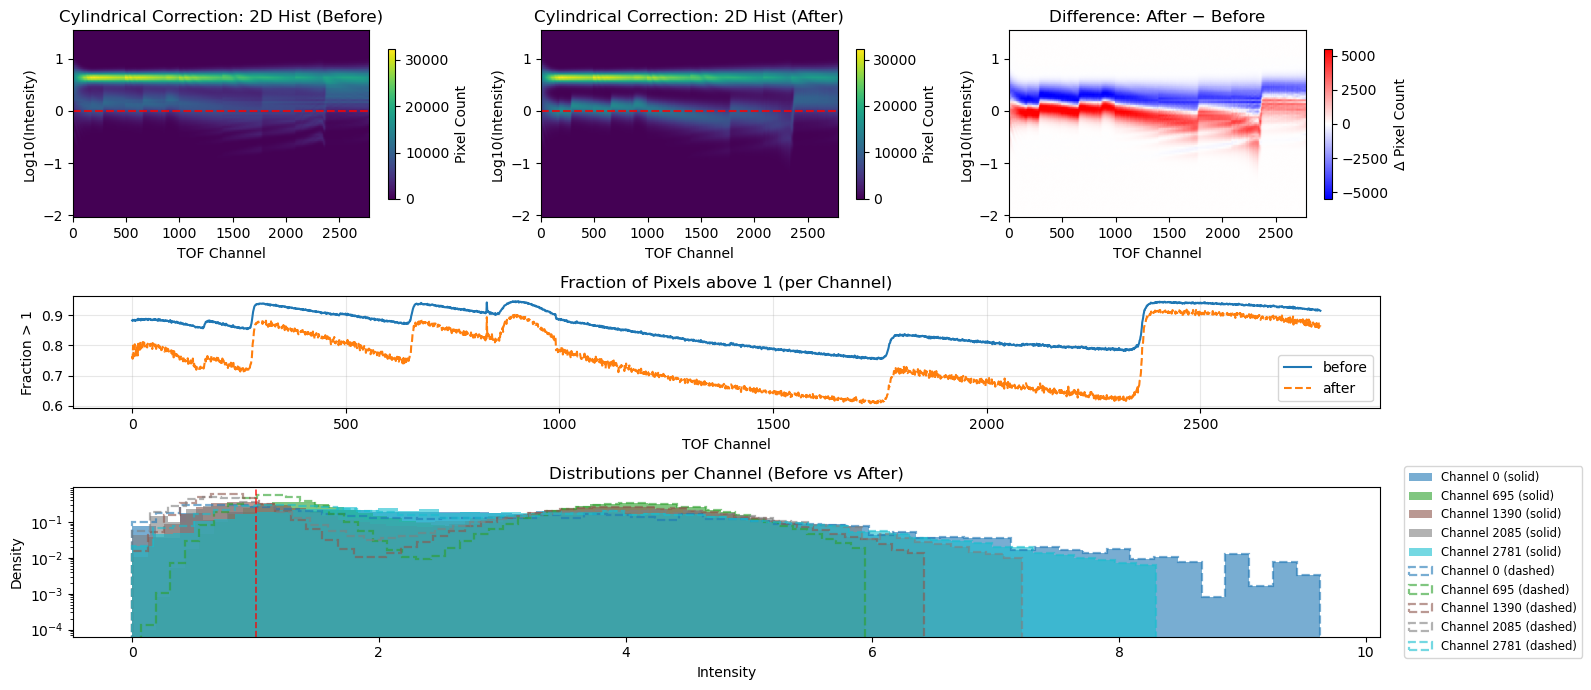

In [29]:
cylindrical_corr_analysis_res = analyze_hyperspectral_comparison(
    T_yxl_before=hyperspectral_stack,
    T_yxl_after=Tcorr,
    title_prefix="Cylindrical Correction"
)

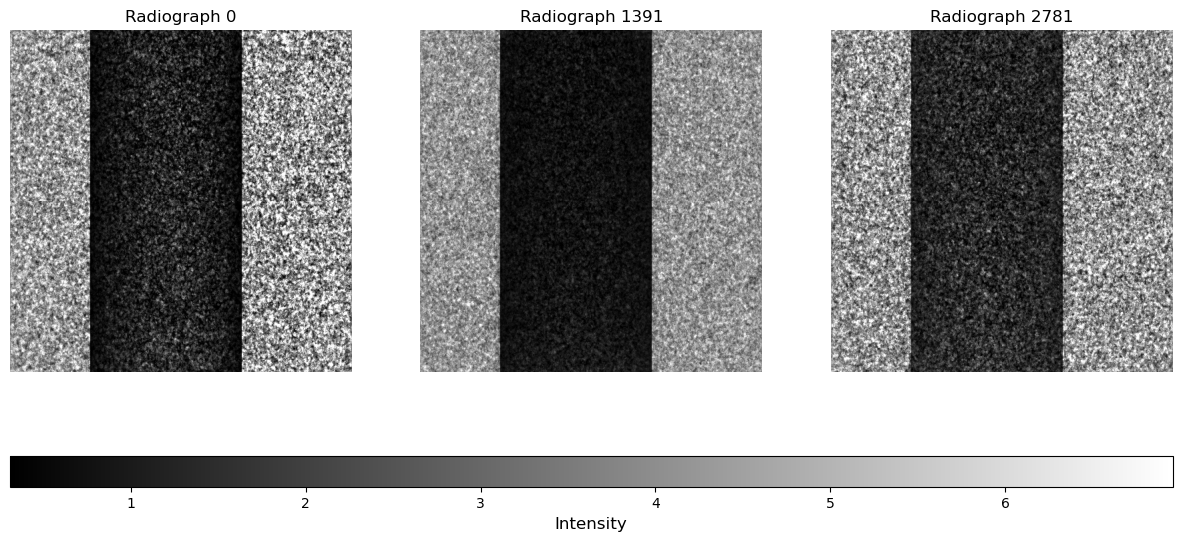

In [30]:
_ = visualize_hyperspectral_radiographs(Tcorr)